In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import requests
import base64
import time

In [2]:
df = pd.read_json("StreamingHistory_music_0.json")


# =========================================
# CREATE YYYY-MM COLUMN
# =========================================

# Convert endTime to datetime
df["endTime"] = pd.to_datetime(df["endTime"])

# Extract only year-month
df["year_month"] = df["endTime"].dt.strftime("%Y-%m")

In [3]:
summary = (
    df.groupby(
        ["year_month", "artistName", "trackName"]
    )
    .agg(
        playCount=("trackName", "count"),
        totalMsPlayed=("msPlayed", "sum")
    )
    .reset_index()
)

In [4]:
summary.to_csv(
    "spotify_summary.csv",
    index=False
)

In [5]:
summary.head()

,year_month,artistName,trackName,playCount,totalMsPlayed
0,2025-08,A.R. Rahman,Enna Sona,4,634647
1,2025-08,A.R. Rahman,Guzarish,3,653970
2,2025-08,A.R. Rahman,Jashn-E-Bahaaraa,5,1260151
3,2025-08,A.R. Rahman,Kaise Mujhe,1,343741
4,2025-08,A.R. Rahman,Maahi Ve,1,240614


In [6]:
CLIENT_ID = "2ace2638f0c049ee8c50d9bd32a50f0d"
CLIENT_SECRET = "8ce36a8d743b4361af6e6acaeccfb971"


# =========================
# GET ACCESS TOKEN
# =========================

def get_token():

    auth_string = f"{CLIENT_ID}:{CLIENT_SECRET}"

    auth_base64 = base64.b64encode(
        auth_string.encode()
    ).decode()

    url = "https://accounts.spotify.com/api/token"

    headers = {
        "Authorization": f"Basic {auth_base64}",
        "Content-Type": "application/x-www-form-urlencoded"
    }

    data = {
        "grant_type": "client_credentials"
    }

    result = requests.post(
        url,
        headers=headers,
        data=data
    )

    token = result.json()["access_token"]

    return token


# =========================
# GET TRACK + ARTIST ID
# =========================

def get_track_and_artist_id(song, artist, token):

    url = "https://api.spotify.com/v1/search"

    headers = {
        "Authorization": f"Bearer {token}"
    }

    query = f"track:{song} artist:{artist}"

    params = {
        "q": query,
        "type": "track",
        "limit": 1
    }

    response = requests.get(
        url,
        headers=headers,
        params=params
    )

    # ERROR CHECK
    if response.status_code != 200:
        print("ERROR:", response.status_code)
        return None

    data = response.json()

    items = data["tracks"]["items"]

    # NO RESULTS
    if len(items) == 0:
        return None

    track = items[0]

    # TRACK ID
    track_id = track["id"]

    # TRACK NAME
    track_name = track["name"]

    # ARTIST INFO
    artist_info = track["artists"][0]

    artist_id = artist_info["id"]
    artist_name = artist_info["name"]

    return {
        "artist_id": artist_id,
        "artist_name": artist_name,
        "song_id": track_id,
        "song_name": track_name
    }

In [7]:
token = get_token()

result = get_track_and_artist_id(
    "Tum Ko Dekha To Yeh Khayal Aaya",
    "Jagjit Singh",
    token
)

print(result)

{'artist_id': '2ijWbN5KykTYiBoVmhzCTU', 'artist_name': 'Jagjit Singh', 'song_id': '79lwJjahpqnJJXo3LJeOoh', 'song_name': 'Tum Ko Dekha To Yeh Khayal Aaya (From "Saath Saath")'}


In [38]:
df = pd.read_csv("spotify_summary.csv")


# =========================================
# GET TOKEN
# =========================================

token = get_token()


# =========================================
# CREATE NEW DATAFRAME
# =========================================

processed_data = []


for index, row in df.iterrows():

    artist = row["artistName"]
    song = row["trackName"]

    print(f"Processing: {song} - {artist}")

    result = get_track_and_artist_id(
        song,
        artist,
        token
    )

    if result is not None:

        processed_data.append({

            "artist_id": result["artist_id"],

            "artist_name": result["artist_name"],

            "song_id": result["song_id"],

            "song_name": result["song_name"],

            "count": row["playCount"],

            "totalMsPlayed": row["totalMsPlayed"],
            "year_month": row["year_month"]

        })

    else:

        processed_data.append({

            "artist_id": None,

            "artist_name": artist,

            "song_id": None,

            "song_name": song,

            "count": row["playCount"],

            "totalMsPlayed": row["totalMsPlayed"],
            "year_month": row["year_month"]

        })

    # avoid rate limiting
    time.sleep(0.2)


# =========================================
# CREATE FINAL DATAFRAME
# =========================================

dtf1 = pd.DataFrame(processed_data)


# =========================================
# SAVE CSV
# =========================================

dtf1.to_csv(
    "userHisoryPreprocessed.csv",
    index=False
)


print("\nDONE")

Processing: Enna Sona - A.R. Rahman
ERROR: 429
Processing: Guzarish - A.R. Rahman
ERROR: 429
Processing: Jashn-E-Bahaaraa - A.R. Rahman
ERROR: 429
Processing: Kaise Mujhe - A.R. Rahman
ERROR: 429
Processing: Maahi Ve - A.R. Rahman
ERROR: 429
Processing: Masti Ki Paathshala - A.R. Rahman
ERROR: 429
Processing: Mayya - A.R. Rahman
ERROR: 429
Processing: Nadaan Parinde - A.R. Rahman
ERROR: 429
Processing: Rait Zara Si (From "Atrangi Re") - A.R. Rahman
ERROR: 429
Processing: Rang De Basanti - A.R. Rahman
ERROR: 429
Processing: Roobaroo - A.R. Rahman
ERROR: 429
Processing: Saathiya - A.R. Rahman
ERROR: 429
Processing: Tere Bina - A.R. Rahman
ERROR: 429
Processing: Tum Tak (From "Raanjhanaa") - A.R. Rahman
ERROR: 429
Processing: Thodi Si Daaru - AP Dhillon
ERROR: 429
Processing: Sahiba - Aditya Rikhari
ERROR: 429
Processing: Tera Chehra - Adnan Sami
ERROR: 429
Processing: Humsafar (From "Badrinath Ki Dulhania") - Akhil Sachdeva
ERROR: 429
Processing: Jo Bhi Kasmein - Alka Yagnik
ERROR: 429
P

KeyboardInterrupt: 

In [39]:
dtf1

,artist_id,artist_name,song_id,song_name,count,totalMsPlayed,year_month
0,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,6bdpj89aYEBjhpsenXAsmO,Enna Sona,4,634647,2025-08
1,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,2MvCNH9ua0CeOgUQfZf56z,Guzarish,3,653970,2025-08
2,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,1O5mTSQa0sCce9ghhDqIZl,Jashn-E-Bahaaraa,5,1260151,2025-08
3,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,53DXM0bHfB7xkqJZYlksuh,Kaise Mujhe,1,343741,2025-08
4,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,1sbW5E7w8tnqpYk0Frx8QG,Maahi Ve,1,240614,2025-08
...,...,...,...,...,...,...,...
727,None,Sachin-Jigar,None,Mileya Mileya,1,1686,2026-04
728,None,Sachin-Jigar,None,"Pardesiya - From ""Param Sundari""",1,231739,2026-04
729,None,Sajid-Wajid,None,Chamak Challo Chel Chabeli,1,4143,2026-04
730,None,Santhosh Narayanan,None,Ei Suzhali,1,1266,2026-04


In [49]:
dtf2 = dtf1


feature_columns = [

    'danceability',
    'energy',
    'valence',
    'tempo',
    'acousticness',
    'instrumentalness',
    'liveness',
    'speechiness',

    # NEW COLUMN
    'genres'
]

for col in feature_columns:

    if col not in dtf2.columns:
        dtf2[col] = None




In [22]:
# dtf2 = pd.read_csv("userHisoryPreprocessed.csv")

In [50]:
dtf2

,artist_id,artist_name,song_id,song_name,count,totalMsPlayed,year_month,danceability,energy,valence,tempo,acousticness,instrumentalness,liveness,speechiness,genres
0,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,6bdpj89aYEBjhpsenXAsmO,Enna Sona,4,634647,2025-08,None,None,None,None,None,None,None,None,None
1,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,2MvCNH9ua0CeOgUQfZf56z,Guzarish,3,653970,2025-08,None,None,None,None,None,None,None,None,None
2,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,1O5mTSQa0sCce9ghhDqIZl,Jashn-E-Bahaaraa,5,1260151,2025-08,None,None,None,None,None,None,None,None,None
3,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,53DXM0bHfB7xkqJZYlksuh,Kaise Mujhe,1,343741,2025-08,None,None,None,None,None,None,None,None,None
4,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,1sbW5E7w8tnqpYk0Frx8QG,Maahi Ve,1,240614,2025-08,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,None,Sachin-Jigar,None,Mileya Mileya,1,1686,2026-04,None,None,None,None,None,None,None,None,None
728,None,Sachin-Jigar,None,"Pardesiya - From ""Param Sundari""",1,231739,2026-04,None,None,None,None,None,None,None,None,None
729,None,Sajid-Wajid,None,Chamak Challo Chel Chabeli,1,4143,2026-04,None,None,None,None,None,None,None,None,None
730,None,Santhosh Narayanan,None,Ei Suzhali,1,1266,2026-04,None,None,None,None,None,None,None,None,None


In [29]:
dtf2.to_csv("temp.csv")

In [42]:
# ==========================================
# GET AUDIO FEATURES
# ==========================================

def get_audio_features(track_id, headers):

    if pd.isna(track_id):
        return {}

    url = (
        "https://spotify-extended-audio-features-api.p.rapidapi.com"
        f"/v1/audio-features/{track_id}"
    )

    try:

        response = requests.get(
            url,
            headers=headers
        )

        time.sleep(1)

        if response.status_code == 200:

            data = response.json()

            return {

                'danceability': data.get('danceability'),

                'energy': data.get('energy'),

                'valence': data.get('valence'),

                'tempo': data.get('tempo'),

                'acousticness': data.get('acousticness'),

                'instrumentalness': data.get('instrumentalness'),

                'liveness': data.get('liveness'),

                'speechiness': data.get('speechiness')

            }

        else:

            print(
                f"AUDIO API ERROR for {track_id}: "
                f"{response.status_code}"
            )

            return {}

    except Exception as e:

        print(
            f"AUDIO REQUEST FAILED for "
            f"{track_id}: {e}"
        )

        return {}



In [32]:
# ==========================================
# GET ARTIST GENRES
# ==========================================

def get_artist_genres(artist_id, headers):

    if pd.isna(artist_id):
        return None

    url = (
        "https://spotify-extended-audio-features-api.p.rapidapi.com"
        f"/v1/artists/{artist_id}"
    )

    try:

        response = requests.get(
            url,
            headers=headers
        )

        time.sleep(1)

        if response.status_code == 200:

            data = response.json()

            genres = data.get("genres", [])

            # convert list → string
            genre_string = ", ".join(genres)

            return genre_string

        else:

            print(
                f"ARTIST API ERROR for "
                f"{artist_id}: {response.status_code}"
            )

            return None

    except Exception as e:

        print(
            f"ARTIST REQUEST FAILED for "
            f"{artist_id}: {e}"
        )

        return None


In [ ]:
# genres = get_artist_genres(
#             "1mYsTxnqsietFxj1OgoGbG"
#         )

In [ ]:
# genres

In [77]:
headers = {
    "x-rapidapi-key": "8814ea78a1msh30614356e5ec298p15f105jsnbbc911375a5f",
    "x-rapidapi-host": "spotify-extended-audio-features-api.p.rapidapi.com"
}

In [78]:
# ==========================================
# FIND UNPROCESSED ROWS
# ==========================================

# if danceability OR genres missing,
# treat as unprocessed

unprocessed_mask = (

    (
        dtf2['danceability'].isna()
        |
        dtf2['genres'].isna()
    )

    &

    dtf2['song_id'].notna()

)


# ==========================================
# TAKE NEXT 5 ROWS
# ==========================================

batch_to_process = dtf2[
    unprocessed_mask
].head(5)


# ==========================================
# PROCESS BATCH
# ==========================================

if batch_to_process.empty:

    print("ALL TRACKS PROCESSED")

else:

    print(
        f"Processing next "
        f"{len(batch_to_process)} tracks..."
    )

    for idx, row in batch_to_process.iterrows():

        track_id = row['song_id']
        artist_id = row['artist_id']

        print(
            f"\nProcessing:\n"
            f"Track: {track_id}\n"
            f"Artist: {artist_id}"
        )

        # ==================================
        # AUDIO FEATURES
        # ==================================

        audio_features = get_audio_features(
            track_id, headers
        )

        # ==================================
        # GENRES
        # ==================================

        genres = get_artist_genres(
            artist_id, headers
        )

        # ==================================
        # UPDATE DATAFRAME
        # ==================================

        for key, value in audio_features.items():

            dtf2.at[idx, key] = value

        dtf2.at[idx, 'genres'] = genres

        print("DONE")

# ==========================================
# SAVE UPDATED CSV
# ==========================================

dtf2.to_csv(
    "userHisoryPreprocessed.csv",
    index=False
)

print(
    "\nUPDATED CSV SAVED"
)

Processing next 5 tracks...

Processing:
Track: 0a9pJv0X1QMvBWkq0mC1Bx
Artist: 1UdYhDdrXVNJMAKghjdU6v
AUDIO API ERROR for 0a9pJv0X1QMvBWkq0mC1Bx: 404
DONE

Processing:
Track: 3YABmYlJLVsnkfQD3jwcH9
Artist: 00sCATpEvwH48ays7PlQFU
AUDIO API ERROR for 3YABmYlJLVsnkfQD3jwcH9: 404
DONE

Processing:
Track: 0Fyxf85bMharfLXF7BMnRr
Artist: 4oVMLzAqW6qhRpZWt8fNw4
DONE

Processing:
Track: 2vR23BjIzpLMtzsyKrM6Mb
Artist: 4oVMLzAqW6qhRpZWt8fNw4
DONE

Processing:
Track: 77IPBSEbMAiH7gOGfLllKz
Artist: 4oVMLzAqW6qhRpZWt8fNw4
DONE

UPDATED CSV SAVED


In [ ]:
print(dtf2.columns.tolist())

In [80]:
dtf2.head(40)

,artist_id,artist_name,song_id,song_name,count,totalMsPlayed,year_month,danceability,energy,valence,tempo,acousticness,instrumentalness,liveness,speechiness,genres
0,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,6bdpj89aYEBjhpsenXAsmO,Enna Sona,4,634647,2025-08,0.717,0.415,0.379,100.021,0.637,0.000001,0.0976,0.0302,"tamil pop, kollywood, sufi, bollywood, hindi p..."
1,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,2MvCNH9ua0CeOgUQfZf56z,Guzarish,3,653970,2025-08,0.595,0.624,0.647,170.001,0.0925,0.0,0.114,0.0603,"tamil pop, kollywood, sufi, bollywood, hindi p..."
2,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,1O5mTSQa0sCce9ghhDqIZl,Jashn-E-Bahaaraa,5,1260151,2025-08,0.7,0.343,0.488,137.864,0.767,0.0,0.0789,0.0308,"tamil pop, kollywood, sufi, bollywood, hindi p..."
3,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,53DXM0bHfB7xkqJZYlksuh,Kaise Mujhe,1,343741,2025-08,0.59,0.414,0.292,82.002,0.781,0.000522,0.146,0.0346,"tamil pop, kollywood, sufi, bollywood, hindi p..."
4,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,1sbW5E7w8tnqpYk0Frx8QG,Maahi Ve,1,240614,2025-08,0.604,0.72,0.528,130.995,0.571,0.000012,0.12,0.0603,"tamil pop, kollywood, sufi, bollywood, hindi p..."
5,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,2cZ2Q33G9mkS8fIVKM591T,Masti Ki Paathshala,1,219853,2025-08,0.845,0.686,0.874,146.954,0.00131,0.000053,0.129,0.0781,"tamil pop, kollywood, sufi, bollywood, hindi p..."
6,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,0hp4qW1zgKnBBiyyAdW3Sz,Mayya,1,236618,2025-08,0.746,0.565,0.462,100.972,0.122,0.000286,0.0904,0.101,"tamil pop, kollywood, sufi, bollywood, hindi p..."
7,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,6Z394Nd4gW6Ts9hmu3NUjx,Nadaan Parinde,1,384000,2025-08,0.507,0.741,0.492,132.903,0.414,0.000004,0.107,0.0535,"tamil pop, kollywood, sufi, bollywood, hindi p..."
8,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,4uK0M8AI6gyFmyzUneQpbi,"Rait Zara Si (From ""Atrangi Re"")",1,29541,2025-08,0.563,0.495,0.244,125.998,0.781,0.0,0.0837,0.0362,"tamil pop, kollywood, sufi, bollywood, hindi p..."
9,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,1SdFBc40uBU5Pqylo05VIC,Rang De Basanti,1,363800,2025-08,0.848,0.925,0.69,105.006,0.054,0.104,0.209,0.0767,"tamil pop, kollywood, sufi, bollywood, hindi p..."


In [81]:
dtf3=dtf2

In [85]:
dtf3.dropna(inplace=True)

In [86]:
dtf3['genre_list'] = dtf2.head(40)['genres'].apply(lambda x: x.split(', '))

In [87]:
dtf3['genre_list']

,genre_list
0,"[tamil pop, kollywood, sufi, bollywood, hindi ..."
1,"[tamil pop, kollywood, sufi, bollywood, hindi ..."
2,"[tamil pop, kollywood, sufi, bollywood, hindi ..."
3,"[tamil pop, kollywood, sufi, bollywood, hindi ..."
4,"[tamil pop, kollywood, sufi, bollywood, hindi ..."
5,"[tamil pop, kollywood, sufi, bollywood, hindi ..."
6,"[tamil pop, kollywood, sufi, bollywood, hindi ..."
7,"[tamil pop, kollywood, sufi, bollywood, hindi ..."
8,"[tamil pop, kollywood, sufi, bollywood, hindi ..."
9,"[tamil pop, kollywood, sufi, bollywood, hindi ..."


In [88]:
all_unique_genres = dtf3['genre_list'].dropna().explode().unique()

for genre_name in all_unique_genres:
    print(f"Processing genre: {genre_name}")
    dtf3[genre_name] = dtf3['genre_list'].apply(lambda x: 1 if isinstance(x, list) and genre_name in x else 0)

Processing genre: tamil pop
Processing genre: kollywood
Processing genre: sufi
Processing genre: bollywood
Processing genre: hindi pop
Processing genre: desi
Processing genre: tamil dance
Processing genre: punjabi hip hop
Processing genre: punjabi pop
Processing genre: bhangra
Processing genre: desi hip hop
Processing genre: desi pop
Processing genre: hindi indie
Processing genre: indian indie
Processing genre: qawwali
Processing genre: ghazal
Processing genre: telugu pop
Processing genre: tollywood
Processing genre: gujarati garba
Processing genre: gujarati pop
Processing genre: bangla pop
Processing genre: kannada pop
Processing genre: 
Processing genre: soft pop
Processing genre: marathi pop


In [89]:
dtf3

,artist_id,artist_name,song_id,song_name,count,totalMsPlayed,year_month,danceability,energy,valence,...,ghazal,telugu pop,tollywood,gujarati garba,gujarati pop,bangla pop,kannada pop,,soft pop,marathi pop
0,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,6bdpj89aYEBjhpsenXAsmO,Enna Sona,4,634647,2025-08,0.717,0.415,0.379,...,0,0,0,0,0,0,0,0,0,0
1,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,2MvCNH9ua0CeOgUQfZf56z,Guzarish,3,653970,2025-08,0.595,0.624,0.647,...,0,0,0,0,0,0,0,0,0,0
2,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,1O5mTSQa0sCce9ghhDqIZl,Jashn-E-Bahaaraa,5,1260151,2025-08,0.7,0.343,0.488,...,0,0,0,0,0,0,0,0,0,0
3,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,53DXM0bHfB7xkqJZYlksuh,Kaise Mujhe,1,343741,2025-08,0.59,0.414,0.292,...,0,0,0,0,0,0,0,0,0,0
4,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,1sbW5E7w8tnqpYk0Frx8QG,Maahi Ve,1,240614,2025-08,0.604,0.72,0.528,...,0,0,0,0,0,0,0,0,0,0
5,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,2cZ2Q33G9mkS8fIVKM591T,Masti Ki Paathshala,1,219853,2025-08,0.845,0.686,0.874,...,0,0,0,0,0,0,0,0,0,0
6,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,0hp4qW1zgKnBBiyyAdW3Sz,Mayya,1,236618,2025-08,0.746,0.565,0.462,...,0,0,0,0,0,0,0,0,0,0
7,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,6Z394Nd4gW6Ts9hmu3NUjx,Nadaan Parinde,1,384000,2025-08,0.507,0.741,0.492,...,0,0,0,0,0,0,0,0,0,0
8,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,4uK0M8AI6gyFmyzUneQpbi,"Rait Zara Si (From ""Atrangi Re"")",1,29541,2025-08,0.563,0.495,0.244,...,0,0,0,0,0,0,0,0,0,0
9,1mYsTxnqsietFxj1OgoGbG,A.R. Rahman,1SdFBc40uBU5Pqylo05VIC,Rang De Basanti,1,363800,2025-08,0.848,0.925,0.69,...,0,0,0,0,0,0,0,0,0,0


In [91]:
genre_counts=dtf3.iloc[:, 17:].sum()

In [ ]:
genre_counts

,0
tamil pop,22
kollywood,22
sufi,26
bollywood,36
hindi pop,34
desi,32
tamil dance,22
punjabi hip hop,1
punjabi pop,2
bhangra,2


In [92]:
genre_df = genre_counts.reset_index()
genre_df.columns = ['genre', 'frequency']

In [93]:
genre_df

,genre,frequency
0,tamil pop,14
1,kollywood,14
2,sufi,19
3,bollywood,34
4,hindi pop,32
5,desi,26
6,tamil dance,14
7,punjabi hip hop,1
8,punjabi pop,1
9,bhangra,1


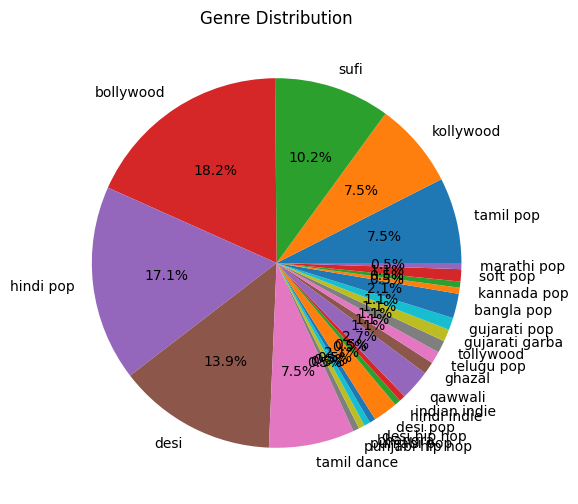

In [94]:
plt.figure(figsize=(6,6))

plt.pie(
    genre_df['frequency'],
    labels=genre_df['genre'],
    autopct='%1.1f%%'
)

plt.title('Genre Distribution')

plt.show()

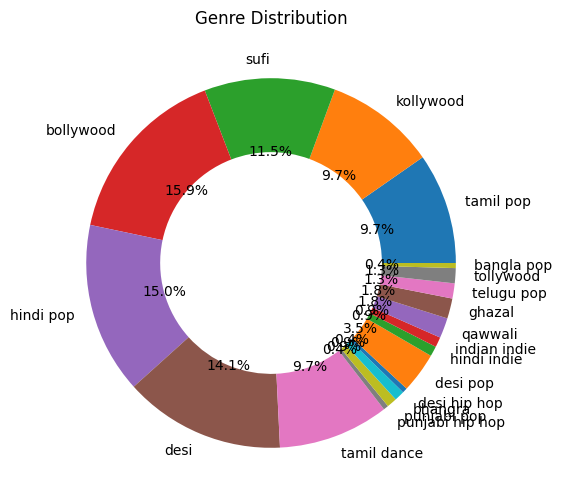

### TOP 5 ARTISTS BASED ON FREQUENCY

### TOP ARTISTS

In [96]:
artist_count=dtf3.iloc[:, 1].groupby(dtf3.iloc[:, 1]).count()

In [97]:
top_5_artists = artist_count.sort_values(ascending=False).head(5)

In [98]:
top_5_artists

,artist_name
artist_name,
A.R. Rahman,14
Atif Aslam,4
Kailash Kher,3
Amit Trivedi,2
Alka Yagnik,2


In [99]:
top_5_df = top_5_artists.rename('count').reset_index()

top_5_df

,artist_name,count
0,A.R. Rahman,14
1,Atif Aslam,4
2,Kailash Kher,3
3,Amit Trivedi,2
4,Alka Yagnik,2


### Top 10 played tracks (overall)

In [100]:
# ==========================================
# TOP 5 MOST PLAYED TRACKS
# ==========================================

top_tracks = (
    dtf3.groupby("song_name")["count"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
)

print(top_tracks)

song_name
Hey Ya !                       7
Iktara (From "Wake Up Sid")    5
Jashn-E-Bahaaraa               5
Tum Tak (From "Raanjhanaa")    5
Perfect                        5
Name: count, dtype: int64
